# ex005: TD学習によるモデルフリーオフ方策学習 — Q学習(Q-Learning)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/yryo1005/TicTacToe_Reinforcement_Learning_training/blob/main/ex005_q_learning.ipynb)

1ステップごとにTD誤差でQ(s,a)を更新するQ学習を実装し，ex004(モンテカルロ制御)と比較する．

理論的な背景・実験条件・考察・発展課題は [ex005_q_learning.md](ex005_q_learning.md) を参照．

## 共通コンポーネント

環境(`TicTacToeEnv`)・エージェント(`BaseAgent`系のクラス)・評価関数(`evaluate`, `play_human_vs_ai`)・ロガー(`ResultLogger`)の実装．全実験(ex001〜ex006)で共通である．

In [1]:
import os
import json
import random
import time
import subprocess
from itertools import product

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# グラフ中の日本語(軸ラベル・タイトル等)を正しく表示するため, 日本語フォント(IPAexGothic)を
# 使用する. Google Colabの標準イメージには日本語フォントが含まれていないため, 見つからない
# 場合はaptで補い, フォントキャッシュを再構築してから設定する(失敗しても実行は継続する).
if "IPAexGothic" not in {f.name for f in fm.fontManager.ttflist}:
    try:
        subprocess.run(
            ["apt-get", "-qq", "install", "-y", "fonts-ipaexfont-gothic"],
            check=False, capture_output=True,
        )
        fm.fontManager.addfont(
            "/usr/share/fonts/opentype/ipaexfont-gothic/ipaexg.ttf"
        )
    except Exception:
        pass
plt.rcParams["font.family"] = "IPAexGothic"
plt.rcParams["axes.unicode_minus"] = False


def set_seed(seed: int = 0) -> None:
    """
    実験の再現性を確保するため, Python標準のrandomおよびNumPyの乱数シードを固定する.

    引数:
        seed (int): 固定する乱数シード値. デフォルトは0.
    戻り値:
        なし.
    """
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)


In [2]:
class ResultLogger:
    """
    学習中の各種指標(勝率, 価値関数の差分など)の推移をメモリ上に記録し,
    JSONファイルとして保存・読み込みを行う軽量なロガークラス.
    """

    def __init__(self, target_path: str = None):
        """
        引数:
            target_path (str): 既存のログファイルのパス. Noneの場合は新規に初期化する.
        戻り値:
            なし.
        """
        self.names = None
        self.history = {}
        if target_path:
            self.load(target_path)

    def set_names(self, *names: str) -> None:
        """
        記録する指標の名前を登録する.

        引数:
            *names (str): 記録したい指標名(例: "win_rate", "delta").
        戻り値:
            なし.
        """
        if self.names:
            raise ValueError("names はすでに設定されています.")
        self.names = list(names)
        for name in self.names:
            if name not in self.history:
                self.history[name] = []

    def __call__(self, *values) -> None:
        """
        指標の値を履歴に追加する.

        引数:
            *values (float | int): set_namesで登録した順序に対応する値.
        戻り値:
            なし.
        """
        if self.names is None:
            raise ValueError("先に set_names を実行してください.")
        if len(values) != len(self.names):
            raise ValueError("valuesの個数がnamesの個数と一致しません.")
        for name, value in zip(self.names, values):
            self.history[name].append(value)

    def save(self, target_path: str) -> None:
        """
        記録された履歴をJSONファイルとして保存する.

        引数:
            target_path (str): 保存先のファイルパス.
        戻り値:
            なし.
        """
        os.makedirs(os.path.dirname(target_path), exist_ok=True)
        with open(target_path, "w") as f:
            json.dump(self.history, f, indent=4, ensure_ascii=False)

    def load(self, target_path: str) -> None:
        """
        保存されたJSONファイルから履歴データを読み込む.

        引数:
            target_path (str): 読み込むファイルパス.
        戻り値:
            なし.
        """
        with open(target_path, "r") as f:
            data = json.load(f)
        self.history = data
        self.names = list(data.keys())

    def __getitem__(self, key: str):
        """
        引数:
            key (str): 指標名.
        戻り値:
            list: 履歴リスト. 存在しない場合は空リスト.
        """
        return self.history.get(key, [])


In [3]:
class TicTacToeEnv:
    """
    3目並べの環境クラス.

    学習エージェントは常に先手(X, セル値1)とし, 後手(O, セル値2)は
    合法手から一様ランダムに選択する固定方策に従う「環境の一部」として扱う.
    この定式化により, 方策反復法・価値反復法が要求する既知の遷移確率 p(s'|s,a) を
    ゲーム規則から解析的に計算できる1エージェント視点のMDPとなる.

    状態は盤面9マスをタプルで表現し, 各要素は 0(空), 1(X), 2(O) を取る.
    状態ID (state_id) は3進数エンコード state_id = Σ_i board[i]・3^i (0 <= state_id < 3^9)
    により, NumPy配列のインデックスとして利用できる整数に変換したものである.
    """

    EMPTY, X, O = 0, 1, 2
    N_CELLS = 9
    N_STATES = 3 ** 9
    LINES = [
        (0, 1, 2), (3, 4, 5), (6, 7, 8),
        (0, 3, 6), (1, 4, 7), (2, 5, 8),
        (0, 4, 8), (2, 4, 6),
    ]

    def __init__(self, opponent_seed: int = None):
        """
        引数:
            opponent_seed (int): 後手(固定ランダム方策)の乱数シード.
        戻り値:
            なし.
        """
        self.rng = np.random.default_rng(opponent_seed)
        self.board = None

    def reset(self) -> tuple:
        """
        盤面を空の状態に初期化する.

        引数:
            なし.
        戻り値:
            tuple[int]: 初期状態(長さ9, 全て空).
        """
        self.board = tuple([self.EMPTY] * self.N_CELLS)
        return self.board

    @classmethod
    def get_valid_actions(cls, state: tuple) -> list:
        """
        引数:
            state (tuple[int]): 盤面の状態. 長さ9.
        戻り値:
            list[int]: 選択可能な行動(空きマスのインデックス)のリスト.
        """
        return [i for i, c in enumerate(state) if c == cls.EMPTY]

    @classmethod
    def check_winner(cls, state: tuple) -> int:
        """
        引数:
            state (tuple[int]): 盤面の状態. 長さ9.
        戻り値:
            int: 勝者(1=X, 2=O). 勝者がいない場合は0.
        """
        for a, b, c in cls.LINES:
            if state[a] != cls.EMPTY and state[a] == state[b] == state[c]:
                return state[a]
        return cls.EMPTY

    @classmethod
    def is_draw(cls, state: tuple) -> bool:
        """
        引数:
            state (tuple[int]): 盤面の状態. 長さ9.
        戻り値:
            bool: 全マスが埋まっており, かつ勝者がいなければTrue.
        """
        return cls.EMPTY not in state and cls.check_winner(state) == cls.EMPTY

    def step(self, action: int):
        """
        エージェント(X)が行動した後, 非終端であれば続けて後手(O, 固定ランダム方策)が
        行動する. Xから見た報酬・終了フラグを返す.

        引数:
            action (int): エージェントが選択する行動(空きマスのインデックス).
        戻り値:
            next_state (tuple[int]): 遷移後の状態.
            reward (float): Xから見た報酬. 勝ち=1.0, 負け=-1.0, 引き分け=0.0, 非終端=0.0.
            done (bool): エピソードが終了したか.
            info (dict): 追加情報(常に空の辞書).
        """
        assert self.board[action] == self.EMPTY, "選択した行動は空きマスではありません."
        board = list(self.board)
        board[action] = self.X
        board = tuple(board)

        if self.check_winner(board) == self.X:
            self.board = board
            return board, 1.0, True, {}
        if self.is_draw(board):
            self.board = board
            return board, 0.0, True, {}

        opponent_action = int(self.rng.choice(self.get_valid_actions(board)))
        board2 = list(board)
        board2[opponent_action] = self.O
        board2 = tuple(board2)

        if self.check_winner(board2) == self.O:
            self.board = board2
            return board2, -1.0, True, {}
        if self.is_draw(board2):
            self.board = board2
            return board2, 0.0, True, {}

        self.board = board2
        return board2, 0.0, False, {}

    def transition_model(self, state: tuple, action: int) -> list:
        """
        動的計画法(方策反復法・価値反復法)で用いる既知の環境モデル p(s'|s,a) を計算する.
        後手が合法手から一様ランダムに選択するという固定方策を仮定し,
        エージェントの行動後に生じうる全ての遷移とその確率を解析的に列挙する.

        引数:
            state (tuple[int]): Xの手番かつ非終端の状態.
            action (int): エージェントが選択する行動.
        戻り値:
            list[tuple]: (next_state, prob, reward, done) のリスト. probの総和は1になる.
        """
        assert state[action] == self.EMPTY
        board = list(state)
        board[action] = self.X
        board = tuple(board)

        if self.check_winner(board) == self.X:
            return [(board, 1.0, 1.0, True)]
        if self.is_draw(board):
            return [(board, 1.0, 0.0, True)]

        opponent_actions = self.get_valid_actions(board)
        prob = 1.0 / len(opponent_actions)
        outcomes = []
        for a in opponent_actions:
            board2 = list(board)
            board2[a] = self.O
            board2 = tuple(board2)
            if self.check_winner(board2) == self.O:
                outcomes.append((board2, prob, -1.0, True))
            elif self.is_draw(board2):
                outcomes.append((board2, prob, 0.0, True))
            else:
                outcomes.append((board2, prob, 0.0, False))
        return outcomes

    def enumerate_states(self):
        """
        ゲーム規則に従って到達可能な全ての盤面を列挙し,
        動的計画法の反復対象となる「Xの手番かつ非終端」の状態集合を求める.

        引数:
            なし.
        戻り値:
            x_turn_states (set[tuple]): Xの手番かつ非終端の到達可能状態の集合.
            all_states (set[tuple]): 終端状態を含む到達可能な全状態の集合.
        """
        start = tuple([self.EMPTY] * self.N_CELLS)
        all_states = {start}
        x_turn_states = set()
        stack = [(start, self.X)]
        while stack:
            board, turn = stack.pop()
            if self.check_winner(board) != self.EMPTY or self.is_draw(board):
                continue
            if turn == self.X:
                x_turn_states.add(board)
            for a in self.get_valid_actions(board):
                nb = list(board)
                nb[a] = turn
                nb = tuple(nb)
                if nb not in all_states:
                    all_states.add(nb)
                    stack.append((nb, self.O if turn == self.X else self.X))
        return x_turn_states, all_states

    @staticmethod
    def encode_state(state: tuple) -> int:
        """
        引数:
            state (tuple[int]): 盤面の状態. 長さ9, 各要素は{0,1,2}.
        戻り値:
            int: 状態ID (0以上 3^9 未満).
        """
        return sum(c * (3 ** i) for i, c in enumerate(state))

    @staticmethod
    def decode_state(state_id: int) -> tuple:
        """
        引数:
            state_id (int): 状態ID (0以上 3^9 未満).
        戻り値:
            tuple[int]: 盤面の状態. 長さ9.
        """
        board = []
        for _ in range(TicTacToeEnv.N_CELLS):
            board.append(state_id % 3)
            state_id //= 3
        return tuple(board)

    @classmethod
    def render(cls, state: tuple, show_indices: bool = False) -> None:
        """
        盤面を人間が読める形式で標準出力に表示する.

        引数:
            state (tuple[int]): 盤面の状態. 長さ9.
            show_indices (bool): Trueの場合, 空きマスをそのセル番号(0-8)で表示する.
        戻り値:
            なし.
        """
        symbols = {cls.EMPTY: ".", cls.X: "X", cls.O: "O"}
        cells = []
        for i, c in enumerate(state):
            cells.append(str(i) if (c == cls.EMPTY and show_indices) else symbols[c])
        rows = [" ".join(cells[r * 3:(r + 1) * 3]) for r in range(3)]
        print("\n".join(rows))


In [4]:
class BaseAgent:
    """
    全エージェントの基底クラス. select_actionのインタフェースのみを定める.
    """

    def select_action(self, state: tuple, valid_actions: list) -> int:
        """
        引数:
            state (tuple[int]): 現在の状態.
            valid_actions (list[int]): 選択可能な行動の一覧.
        戻り値:
            int: 選択した行動.
        """
        raise NotImplementedError

    def update(self, *args, **kwargs) -> None:
        """
        エージェントの内部パラメータを更新する. 学習しないエージェントでは何もしない.

        引数:
            *args, **kwargs: アルゴリズムごとに異なる更新に必要な情報.
        戻り値:
            なし.
        """
        pass


class RandomAgent(BaseAgent):
    """
    合法手から一様ランダムに行動を選択するエージェント. 全実験でベースラインとして使用する.
    """

    def __init__(self, seed: int = None):
        """
        引数:
            seed (int): 乱数シード.
        戻り値:
            なし.
        """
        self.rng = np.random.default_rng(seed)

    def select_action(self, state: tuple, valid_actions: list) -> int:
        """
        引数:
            state (tuple[int]): 現在の状態(本エージェントでは使用しない).
            valid_actions (list[int]): 選択可能な行動の一覧.
        戻り値:
            int: 一様ランダムに選択した行動.
        """
        return int(self.rng.choice(valid_actions))


class TabularQAgent(BaseAgent):
    """
    状態行動価値 Q(s,a) のNumPy配列(形状 (3**9, 9)) に基づき,
    貪欲(greedy)に行動を選択するエージェント.
    動的計画法・モンテカルロ法・Q学習など, テーブル型の価値関数を学習する
    全ての手法の最終的な方策として共通に用いる.
    """

    def __init__(self, Q: np.ndarray):
        """
        引数:
            Q (np.ndarray): 形状 (3**9, 9) の行動価値テーブル.
        戻り値:
            なし.
        """
        self.Q = Q

    def select_action(self, state: tuple, valid_actions: list) -> int:
        """
        引数:
            state (tuple[int]): 現在の状態.
            valid_actions (list[int]): 選択可能な行動の一覧.
        戻り値:
            int: Q(s,a)が最大となる行動(貪欲方策).
        """
        state_id = TicTacToeEnv.encode_state(state)
        qs = self.Q[state_id, valid_actions]
        return valid_actions[int(np.argmax(qs))]


class HumanAgent(BaseAgent):
    """
    標準入力を通じて人間が行動を選択するエージェント. play_human_vs_aiで使用する.
    """

    def select_action(self, state: tuple, valid_actions: list) -> int:
        """
        引数:
            state (tuple[int]): 現在の状態.
            valid_actions (list[int]): 選択可能な行動の一覧.
        戻り値:
            int: 人間が入力した行動.
        """
        TicTacToeEnv.render(state, show_indices=True)
        while True:
            raw = input(f"手を選んでください {valid_actions}: ")
            try:
                a = int(raw)
            except ValueError:
                print("数字で入力してください.")
                continue
            if a in valid_actions:
                return a
            print("その手は選択できません.")


In [5]:
def play_one_game(agent_x: "BaseAgent", agent_o: "BaseAgent", render: bool = False) -> int:
    """
    1エピソード分, agent_x(先手, X)とagent_o(後手, O)を対戦させる.
    動的計画法・モンテカルロ法・Q学習の学習ループが用いるTicTacToeEnv.step
    (後手が固定ランダム方策である学習専用の環境)とは異なり,
    任意の2エージェント同士を対戦させるための汎用ループである.
    evaluate, play_human_vs_ai, および比較実験でのエージェント同士の対戦で共通して使用する.

    引数:
        agent_x (BaseAgent): 先手(X)のエージェント.
        agent_o (BaseAgent): 後手(O)のエージェント.
        render (bool): Trueの場合, 各手番の盤面を表示する.
    戻り値:
        int: 勝者(1=X, 2=O, 0=引き分け).
    """
    board = tuple([TicTacToeEnv.EMPTY] * TicTacToeEnv.N_CELLS)
    turn = TicTacToeEnv.X
    while True:
        valid_actions = TicTacToeEnv.get_valid_actions(board)
        agent = agent_x if turn == TicTacToeEnv.X else agent_o
        action = agent.select_action(board, valid_actions)
        board = tuple(turn if i == action else c for i, c in enumerate(board))
        if render:
            TicTacToeEnv.render(board)
            print("---")
        winner = TicTacToeEnv.check_winner(board)
        if winner != TicTacToeEnv.EMPTY:
            return winner
        if TicTacToeEnv.is_draw(board):
            return TicTacToeEnv.EMPTY
        turn = TicTacToeEnv.O if turn == TicTacToeEnv.X else TicTacToeEnv.X


def evaluate(agent: "BaseAgent", opponent: "BaseAgent" = None, n_episodes: int = 1000, seed: int = 0) -> dict:
    """
    学習したエージェントを, ランダムエージェントや過去の学習済みモデルと対戦させ,
    勝率・引き分け率・敗率を評価する. 評価対象のエージェントは常に先手(X)とする.

    引数:
        agent (BaseAgent): 評価対象のエージェント(先手, X).
        opponent (BaseAgent): 対戦相手. Noneの場合はRandomAgent(seed=seed)を使用する.
        n_episodes (int): 対戦するエピソード数.
        seed (int): 既定のRandomAgentを使用する場合の乱数シード.
    戻り値:
        dict: {"win_rate": float, "draw_rate": float, "lose_rate": float}.
    """
    if opponent is None:
        opponent = RandomAgent(seed=seed)
    wins = draws = losses = 0
    for _ in range(n_episodes):
        winner = play_one_game(agent, opponent)
        if winner == TicTacToeEnv.X:
            wins += 1
        elif winner == TicTacToeEnv.O:
            losses += 1
        else:
            draws += 1
    return {
        "win_rate": wins / n_episodes,
        "draw_rate": draws / n_episodes,
        "lose_rate": losses / n_episodes,
    }


def play_human_vs_ai(agent: "BaseAgent") -> None:
    """
    学習済みエージェント(先手, X)と人間(後手, O)を対人対戦させる.
    Google ColabやローカルのJupyter上でinput()による対話的操作を行う.

    引数:
        agent (BaseAgent): 対戦相手となる学習済みエージェント.
    戻り値:
        なし.
    """
    human = HumanAgent()
    winner = play_one_game(agent, human, render=True)
    if winner == TicTacToeEnv.X:
        print("エージェントの勝利です.")
    elif winner == TicTacToeEnv.O:
        print("あなたの勝利です.")
    else:
        print("引き分けです.")


## Q学習の実装

In [6]:
from collections import defaultdict


class QLearningAgent(BaseAgent):
    """
    Q学習(TD学習, off-policy)によりQ(s,a)を学習するエージェント.
    学習中はepsilon-greedy方策で行動選択を行い, updateメソッドで
    1ステップの遷移ごとにTD誤差に基づく更新を行う.
    ex004のMonteCarloAgentと同じBaseAgentを継承し, updateのみを
    ステップごとのTD更新に置き換えたものである.
    """

    def __init__(self, gamma: float, alpha: float, epsilon: float, seed: int = 0):
        """
        引数:
            gamma (float): 割引率.
            alpha (float): 学習率.
            epsilon (float): epsilon-greedy方策の探索率.
            seed (int): 行動選択に用いる乱数のシード.
        戻り値:
            なし.
        """
        self.gamma = gamma
        self.alpha = alpha
        self.epsilon = epsilon
        self.rng = np.random.default_rng(seed)
        self.Q = defaultdict(float)

    def select_action(self, state: tuple, valid_actions: list) -> int:
        """
        epsilon-greedy方策によって行動を選択する.

        引数:
            state (tuple[int]): 現在の状態.
            valid_actions (list[int]): 選択可能な行動の一覧.
        戻り値:
            int: 選択した行動.
        """
        if self.rng.random() < self.epsilon:
            return int(self.rng.choice(valid_actions))
        qs = [self.Q[(state, a)] for a in valid_actions]
        best = max(qs)
        best_actions = [a for a, q in zip(valid_actions, qs) if q == best]
        return int(self.rng.choice(best_actions))

    def update(self, state: tuple, action: int, reward: float, next_state: tuple,
               done: bool, next_valid_actions: list) -> None:
        """
        TD誤差 delta = r + gamma * max_a' Q(s',a') - Q(s,a) に基づき,
        Q(s,a) <- Q(s,a) + alpha * delta と更新する.

        引数:
            state (tuple[int]): 遷移前の状態 s.
            action (int): 実行した行動 a.
            reward (float): 得られた報酬 r.
            next_state (tuple[int]): 遷移後の状態 s'.
            done (bool): エピソードが終了したか.
            next_valid_actions (list[int]): 次状態で選択可能な行動の一覧(doneの場合は空でよい).
        戻り値:
            なし.
        """
        if done:
            target = reward
        else:
            target = reward + self.gamma * max(self.Q[(next_state, a)] for a in next_valid_actions)
        td_error = target - self.Q[(state, action)]
        self.Q[(state, action)] += self.alpha * td_error

    def to_q_array(self, env: "TicTacToeEnv") -> np.ndarray:
        """
        学習済みのQ(s,a)(辞書)を, NumPy配列(形状(3**9, 9))へ変換する.

        引数:
            env (TicTacToeEnv): 環境.
        戻り値:
            np.ndarray: 形状(3**9, 9)のQ値テーブル. 未訪問の(状態,行動)対は-infとする.
        """
        Q_array = np.full((env.N_STATES, 9), -np.inf)
        for (state, action), value in self.Q.items():
            Q_array[env.encode_state(state), action] = value
        return Q_array


In [7]:
def train_q_learning(env: "TicTacToeEnv", gamma: float, alpha: float, epsilon: float, n_episodes: int,
                      seed: int, eval_every: int = 2000, eval_episodes: int = 300):
    """
    Q学習によりエージェントを学習させる. n_episodes回のエピソードを実行し,
    1ステップごとにTD誤差による更新を行う. eval_everyエピソードごとに
    現在の貪欲方策の勝率を測定して学習曲線として記録する.

    引数:
        env (TicTacToeEnv): 学習に用いる環境(固定ランダム方策の後手を内包).
        gamma (float): 割引率.
        alpha (float): 学習率.
        epsilon (float): epsilon-greedy方策の探索率.
        n_episodes (int): 学習エピソード数.
        seed (int): 乱数シード.
        eval_every (int): 学習曲線を記録する間隔(エピソード数).
        eval_episodes (int): 学習曲線の各点で評価に用いるエピソード数.
    戻り値:
        agent (QLearningAgent): 学習済みエージェント.
        logger (ResultLogger): "episode", "win_rate", "draw_rate", "lose_rate" を記録したロガー.
        train_time (float): 学習に要した時間(秒).
    """
    set_seed(seed)
    env.rng = np.random.default_rng(seed)
    agent = QLearningAgent(gamma=gamma, alpha=alpha, epsilon=epsilon, seed=seed)
    logger = ResultLogger()
    logger.set_names("episode", "win_rate", "draw_rate", "lose_rate")

    t0 = time.time()
    for ep in range(1, n_episodes + 1):
        state = env.reset()
        done = False
        while not done:
            valid_actions = env.get_valid_actions(state)
            action = agent.select_action(state, valid_actions)
            next_state, reward, done, _ = env.step(action)
            next_valid_actions = [] if done else env.get_valid_actions(next_state)
            agent.update(state, action, reward, next_state, done, next_valid_actions)
            state = next_state

        if ep % eval_every == 0:
            eval_agent = TabularQAgent(agent.to_q_array(env))
            result = evaluate(eval_agent, n_episodes=eval_episodes, seed=seed + 9000 + ep)
            logger(ep, result["win_rate"], result["draw_rate"], result["lose_rate"])
    train_time = time.time() - t0
    return agent, logger, train_time


## 実験の設定と実行

In [8]:
EXPERIMENT_NAME = "ex005_tictactoe_td"
ALGORITHM_NAME = "QLearning"
GAMMA = 0.95
ALPHA = 0.1
EPSILON = 0.1
N_EPISODES = 10000
EVAL_EVERY = 500
EVAL_EPISODES_DURING_TRAIN = 300
N_EVAL_EPISODES = 1000
SEEDS = [0, 1, 2]


def run_dir(seed: int) -> str:
    """
    引数:
        seed (int): 実行に用いた乱数シード.
    戻り値:
        str: このシードの結果を保存するディレクトリのパス.
    """
    return os.path.join(
        "outputs", EXPERIMENT_NAME, ALGORITHM_NAME,
        f"gamma{GAMMA}_alpha{ALPHA}_epsilon{EPSILON}", f"seed_{seed}",
    )


In [9]:
for seed in SEEDS:
    target_dir = run_dir(seed)
    eval_path = os.path.join(target_dir, "eval.json")
    if os.path.exists(eval_path):
        print(f"[seed={seed}] 既存の結果が見つかったため学習をスキップします.")
        continue

    env = TicTacToeEnv(opponent_seed=seed)
    agent, logger, train_time = train_q_learning(
        env, GAMMA, ALPHA, EPSILON, N_EPISODES, seed,
        eval_every=EVAL_EVERY, eval_episodes=EVAL_EPISODES_DURING_TRAIN,
    )

    Q_array = agent.to_q_array(env)
    final_agent = TabularQAgent(Q_array)
    final_result = evaluate(final_agent, n_episodes=N_EVAL_EPISODES, seed=seed + 2000)

    os.makedirs(target_dir, exist_ok=True)
    logger.save(os.path.join(target_dir, "log.json"))
    np.save(os.path.join(target_dir, "Q.npy"), Q_array)
    with open(os.path.join(target_dir, "eval.json"), "w") as f:
        json.dump(final_result, f, indent=4, ensure_ascii=False)
    with open(os.path.join(target_dir, "config.json"), "w") as f:
        json.dump(
            {
                "algorithm": ALGORITHM_NAME, "gamma": GAMMA, "alpha": ALPHA, "epsilon": EPSILON,
                "seed": seed, "n_episodes": N_EPISODES, "train_time_sec": train_time,
                "n_eval_episodes": N_EVAL_EPISODES,
            },
            f, indent=4, ensure_ascii=False,
        )
    print(f"[seed={seed}] 学習時間={train_time:.2f}s, 最終評価={final_result}")


[seed=0] 既存の結果が見つかったため学習をスキップします.
[seed=1] 既存の結果が見つかったため学習をスキップします.
[seed=2] 既存の結果が見つかったため学習をスキップします.


## モンテカルロ制御(ex004)との比較・可視化

In [10]:
REPO_URL = "https://github.com/yryo1005/TicTacToe_Reinforcement_Learning_training.git"
REPO_DIR = "TicTacToe_Reinforcement_Learning_training"


def resolve_reference_dir(relative_path: str) -> str:
    """
    他の実験(exNNN)が保存した結果を参照するためのパスを解決する.
    このセッション内で既に生成された outputs/{relative_path} が存在すればそれを使う.
    存在しない場合(Google Colabで本ノートブックのみを単体で開いた場合など)は,
    本リポジトリをクローンし, その中に保存済みのoutputs/{relative_path}を使う.

    引数:
        relative_path (str): outputs/ 以下の相対パス.
    戻り値:
        str: 参照可能なディレクトリのパス.
    """
    local_path = os.path.join("outputs", relative_path)
    if os.path.exists(local_path):
        return local_path
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    cloned_path = os.path.join(REPO_DIR, "outputs", relative_path)
    if not os.path.exists(cloned_path):
        raise FileNotFoundError(
            f"{relative_path} が見つかりません. 対象の実験を先に実行するか, "
            "リポジトリの内容を確認してください."
        )
    return cloned_path


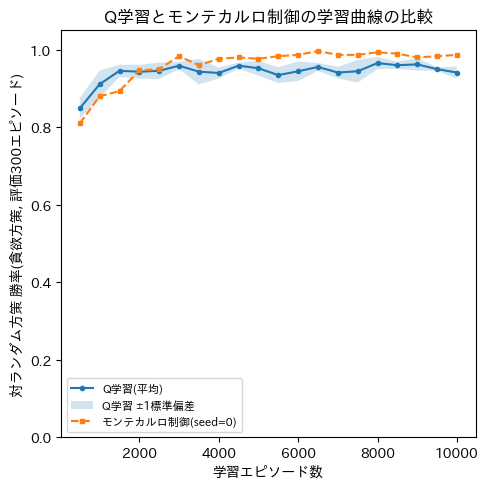

最終評価(n=1000, 3シード平均±標準偏差)
  win_rate  = 0.954 ± 0.008
  draw_rate = 0.040 ± 0.010
  lose_rate = 0.006 ± 0.004


In [11]:
loggers = [ResultLogger(os.path.join(run_dir(seed), "log.json")) for seed in SEEDS]
episodes = loggers[0]["episode"]
win_rates = np.array([lg["win_rate"] for lg in loggers])
mean_win = win_rates.mean(axis=0)
std_win = win_rates.std(axis=0)

mc_log_dir = resolve_reference_dir(
    os.path.join("ex004_tictactoe_mc", "MonteCarloControl", f"gamma{GAMMA}_epsilon{EPSILON}", "seed_0")
)
mc_logger = ResultLogger(os.path.join(mc_log_dir, "log.json"))

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(episodes, mean_win, marker="o", markersize=3, label="Q学習(平均)")
ax.fill_between(episodes, mean_win - std_win, mean_win + std_win, alpha=0.2, label="Q学習 ±1標準偏差")
ax.plot(mc_logger["episode"], mc_logger["win_rate"], marker="s", markersize=3, linestyle="--", label="モンテカルロ制御(seed=0)")
ax.set_xlabel("学習エピソード数")
ax.set_ylabel("対ランダム方策 勝率(貪欲方策, 評価300エピソード)")
ax.set_ylim(0, 1.05)
ax.set_title("Q学習とモンテカルロ制御の学習曲線の比較")
ax.legend(fontsize=8)
fig.tight_layout()

os.makedirs("figures/ex005", exist_ok=True)
fig.savefig("figures/ex005/ql_vs_mc_learning_curve.png", dpi=150)
plt.show()

final_wins, final_draws, final_loses = [], [], []
for seed in SEEDS:
    with open(os.path.join(run_dir(seed), "eval.json")) as f:
        r = json.load(f)
    final_wins.append(r["win_rate"]); final_draws.append(r["draw_rate"]); final_loses.append(r["lose_rate"])
print(f"最終評価(n={N_EVAL_EPISODES}, {len(SEEDS)}シード平均±標準偏差)")
print(f"  win_rate  = {np.mean(final_wins):.3f} ± {np.std(final_wins):.3f}")
print(f"  draw_rate = {np.mean(final_draws):.3f} ± {np.std(final_draws):.3f}")
print(f"  lose_rate = {np.mean(final_loses):.3f} ± {np.std(final_loses):.3f}")
